<a href="https://colab.research.google.com/github/rogers-mbaluka/DS_Course0_Week1_Module2_DataTypes/blob/main/Copy_of_KNN_Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

In this section we will look at an intuitive algorithm known as K-Nearest Neighbors (KNN). KNN is an effective classification and regression algorithm that uses nearby points in order to generate a prediction.


**KNN**

The K-Nearest Neighbors algorithm works as follows:

**Choose a point**

Find the K-nearest points
K is a predefined user constant such as 1, 3, 5, or 11
Predict a label for the current point:
Classification - Take the most common class of the k neighbors
Regression - Take the average target metric of the k neighbors
Both classification or regression can also be modified to use weighted averages based on the distance of the neighbors


**Distance metrics**

An incredibly important decision when using the KNN algorithm is determining an appropriate distance metric. This makes a monumental impact to the output of the algorithm. While there are additional distance metrics, such as cosine distance which we will not cover, you'll get a solid introduction to distance metrics by looking at the standard Euclidean distance and its more generic counterpart, Minkowski distance.

K-means

While outside the scope of this section, it is worth mentioning the related K-means algorithm which uses similar principles as KNN but serves as an unsupervised learning clustering algorithm. In the K-means algorithm, K represents the number of clusters rather then the number of neighbors. Unlike KNN, K-means is an iterative algorithm which repeats until convergence. Nonetheless, its underlying principle is the same, in that it groups data points together using a distance metric in order to create homogeneous groupings.



## How to find the optimal value of K in KNN?


K-Nearest Neighbors is the supervised machine learning algorithm used for classification and regression. It manipulates the training data and classifies the new test data based on distance metrics. It finds the k-nearest neighbors to the test data, and then classification is performed by the majority of class labels.

Selecting the optimal K value to achieve the maximum accuracy of the model is always challenging for a data scientist. I hope you all know the basic idea behind the KNN, yet I will clarify an overview of knn later in this article. For a comprehensive explanation of working of this algorithm, I suggest going through canvas






*   Overview of KNN
*   Distance Metrics
* How to choose a K value?

* KNN model implementation

* Optimization using grid search

* Key Takeaways

## 1. Overview of KNN


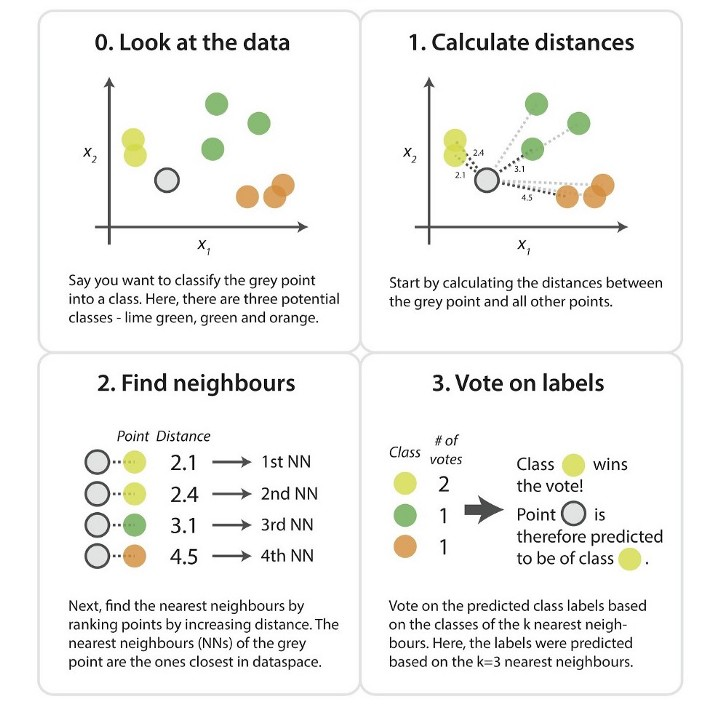

Using K-Nearest Neighbour, we predict the category of the test point from the available class labels by finding the distance between the test point and trained k nearest feature values. By analyzing all the information, you will come up with a question,


**How to calculate the distance?**

Let me answer your enthusiastic question in the next section of distance metrics.

## 2. Distance Metrics
The distance metric is the effective hyper-parameter through which we measure the distance between data feature values and new test inputs.

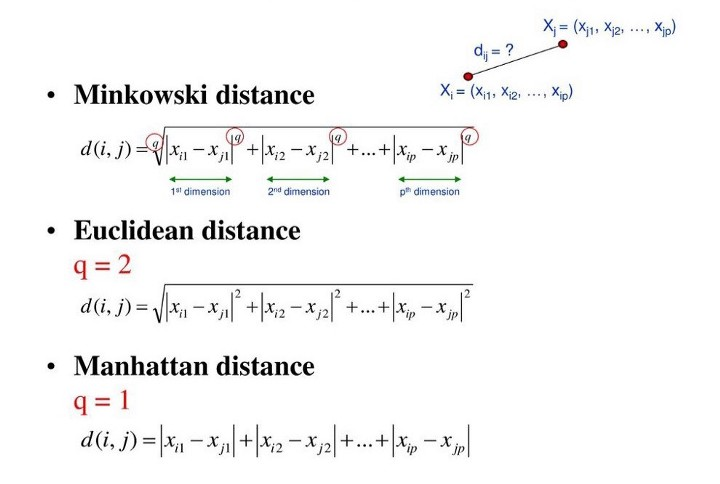

Usually, we use the Euclidean approach, which is the most widely used distance measure to calculate the distance between test samples and trained data values. We measure the distance along a straight line from point (x1, y1) to point (x2, y2).

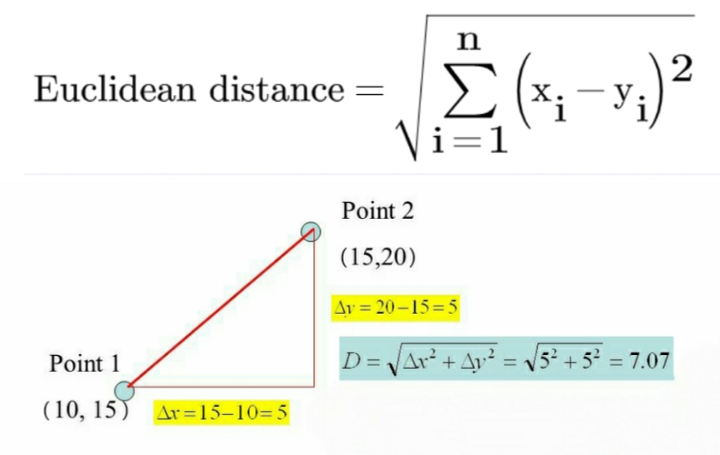

By analyzing the above computations, I hope that you understand how we calculate the Euclidean distance. Let’s throw some light on the prediction method in KNN.

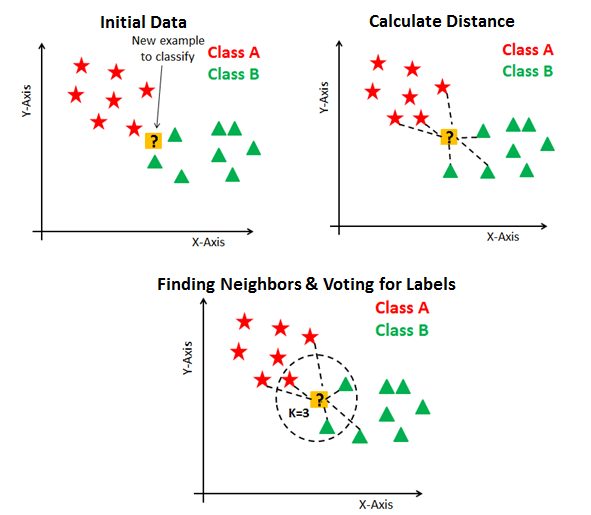



**To classify an unknown record:**

Initialize the K value.

* Calculate the distance between test input and K trained nearest neighbors.

* Check class categories of nearest neighbors and determine the type in which test input falls.

* Classification will be done by taking the majority of votes.

* Return the class category.

We understand the process of classifying an unknown record, but what about choosing an optimal K value?

Lets's Answer it

## 3. How to choose a K value?



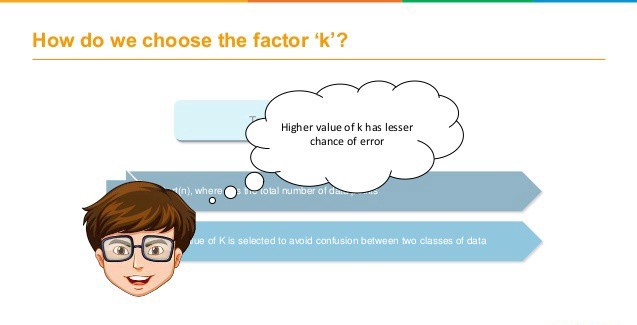

Kvalue indicates the count of the nearest neighbors. We have to compute distances between test points and trained labels points. Updating distance metrics with every iteration is computationally expensive, and that’s why KNN is a lazy learning algorithm

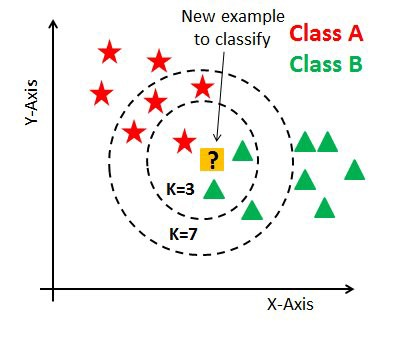

* As you can verify from the above image, if we proceed with K=3, then we predict that test input belongs to class B, and if we continue with K=7, then we predict that test input belongs to class A.

* That’s how you can imagine that the K value has a powerful effect on KNN performance.


**Then how to select the optimal K value?**

* There are no pre-defined statistical methods to find the most favorable value of K.
* Initialize a random K value and start computing.
* Choosing a small value of K leads to unstable decision boundaries.
* The substantial K value is better for classification as it leads to smoothening the decision boundaries.
* Derive a plot between error rate and K denoting values in a defined range. Then choose the K value as having a minimum error rate.
* Now you will get the idea of choosing the optimal K value by implementing the model.

## 4. KNN model implementation
Let’s start the application by importing all the required packages. Then read the telecommunication data file using read_csv() function.





In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import pandas as pd
import matplotlib.ticker as ticker
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
%matplotlib inline

df = pd.read_csv('Telecustomers.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [ ]:
df.shape

> As you can see, there are 12 columns, namely as region, tenure, age, marital, address, income, ed, employ, retire, gender, reside, and custcat. We have a target column, ‘custcat’ categorizes the customers into four groups:

1- Basic Service

2- E-Service

3- Plus Service

4- Total Service

In [ ]:
X = df.drop(['custcat'], axis = 1)
y = df['custcat']

In [ ]:
print(X.shape)
print(y.shape)


In [ ]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


#Train Model and Predict
k = 4
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
Pred_y = neigh.predict(X_test)
print("Accuracy of model at K=4 is",metrics.accuracy_score(y_test, Pred_y))

>* We collect all independent data features into the X data-frame and target field into a y data-frame. Then we manipulate the data and normalize it.

>* After splitting the data, we take 0.8% data for training and remaining for testing purposes.

>* We import the classifier model from the sklearn library and fit the model by initializing K=4. So we have achieved an accuracy of 0.32 here.

Now it’s time to improve the model and find out the optimal k value.

In [ ]:
error_rate = []

for i in range(1,40):
 knn = KNeighborsClassifier(n_neighbors=i)
 knn.fit(X_train,y_train)
 pred_i = knn.predict(X_test)
 error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed',
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate)))

In [ ]:
error_rate

> From the plot, you can see that the smallest error we got is 0.59 at K=37. Further on, we visualize the plot between accuracy and K value.

**Error rate** refers to a measure of the degree of prediction error of a model made with respect to the true model.

In [ ]:
acc = []
# Will take some time
for i in range(1,40,2):
    neigh = KNeighborsClassifier(n_neighbors = i).fit(X_train,y_train)
    yhat = neigh.predict(X_test)
    acc.append(metrics.accuracy_score(y_test, yhat))

plt.figure(figsize=(10,6))
plt.plot(range(1,40,2),acc,color = 'blue',linestyle='dashed',
         marker='o',markerfacecolor='red', markersize=10)
plt.title('accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid("--")
for i, value in enumerate(acc):
    plt.text(i + 1, value + 0.002, f"{value:.2f}",
             ha='center', fontsize=8,rotation=90)
print("Maximum accuracy:-",max(acc),"at K =",acc.index(max(acc)))


* Now you see the improved results. We got the accuracy of 0.41 at K=37. As we already derived the error plot and got the minimum error at k=37, so we will get better efficiency at that K value.

* As our principal focus is on determining optimal K value but, you can perform exploratory data analysis and can achieve even greater accuracy.

### Optimization using grid search

In [ ]:
# -------------------------------
# Grid Search
# -------------------------------

param_grid = {
    'n_neighbors': list(range(1, 40,3)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n========== Grid Search Results ==========")
print("Best Parameters :", grid.best_params_)
print("Best Cross-Validation Accuracy :", round(grid.best_score_,4))

# Best Model
best_knn = grid.best_estimator_

# Predict using the best model
y_pred = best_knn.predict(X_test)

print("Test Accuracy :", round(metrics.accuracy_score(y_test, y_pred),4))

In [ ]:
KNeighborsClassifier()

## 5. Key Takeaways

* We obtained an accuracy of 0.41 at k=37, which is higher than the efficiency calculated at k=4.

* The small K value isn’t suitable for classification.

* The optimal K value usually found is the square root of N, where N is the total number of samples.
* Use an error plot or accuracy plot to find the most favorable K value.
* KNN performs well with multi-label classes, but you must be aware of the outliers.
* KNN is used broadly in the area of pattern recognition and analytical evaluation.

That’s all folks,

# QUESTION?